[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Harvard-CS1090/2026_CS1090B_public/blob/main/sec06/cs1090b_sec06_solutions.ipynb)

# <img style="float: left; padding-right: 10px; width: 45px" src="https://raw.githubusercontent.com/Harvard-IACS/2018-CS109A/master/content/styles/iacs.png">

# CS1090B Section 6: Dimensionality Reduction and Clustering

**Harvard University**<br/>
**Spring 2026**<br/>
**Instructors**: Pavlos Protopapas, Kevin Rader, and Chris Gumb<br/>

## Overview

In this section, we investigate a central question in unsupervised learning:

> **How can we discover structure in high-dimensional data without labels?**

We approach this question in two stages, combining dimensionality reduction with clustering algorithms.

---

**Part 1: Understanding Dimensionality Reduction Methods**

We begin with controlled synthetic datasets where we can observe how different reduction techniques capture different types of structure. In this setting, we:

- Visualize how PCA finds linear structure in correlated data of test scores
- Examine how PCA struggles with non-linear manifolds of spending
- Explore how UMAP's parameters affect local vs. global structure preservation

The goal is not just to apply these techniques, but to understand **when each method is appropriate** and what types of structure they preserve or discard.

---

**Part 2: Dimensionality Reduction + Clustering in Practice (Shape Classification)**

We then move to a more realistic setting: unsupervised analysis of images, and in this case of geometric shapes (stars, ovals, squares, and octagons). Here, we:

- Apply dimensionality reduction to high-dimensional shape representations
- Observe how data clusters emerge in the reduced space
- Use a clustering algorithm ($k$-means)
- Evaluate how well the discovered clusters align with true shape categories

This allows us to see how dimensionality reduction and clustering work together as a *complete unsupervised pipeline* for discovering natural groupings in unlabeled data.

## Learning Objectives

By the end of this section, you should be able to:

### Conceptual Understanding
1. Define dimensionality reduction and explain when it's necessary for high-dimensional data.
2. Explain the difference between linear (PCA) and non-linear (UMAP) dimensionality reduction.
3. Understand how UMAP's hyperparameters affect local vs. global structure preservation.
4. Explain the $k$-means algorithm and its use cases.

### Practical Skills (Dimensionality Reduction + Clustering)
5. Apply PCA and UMAP using scikit-learn to reduce data dimensionality.
6. Visualize high-dimensional data in reduced 2D/1D spaces.
7. Implement a clustering pipeline with appropriate hyperparameter tuning.
8. Evaluate clustering quality using metrics and visual inspection.
9. Build a complete unsupervised pipeline: dimensionality reduction → clustering → evaluation.

## Setup: Download Data

In [1]:
# Environment detection and setup
import os
import subprocess
import sys
import shutil
import zipfile
import urllib.request

# --- Download notebook assets (dataset) ---
assets_zip_url = "https://github.com/Harvard-CS1090/2026_CS1090B_public/raw/main/sec06/notebook_assets.zip"
assets_zip_name = "notebook_assets.zip"
expected_dirs = ["data"]

all_dirs_exist = all(os.path.isdir(d) for d in expected_dirs)

if all_dirs_exist:
    print("Required directories already exist. Skipping asset download.")
else:
    print(f"Downloading {assets_zip_name} from GitHub...")
    try:
        if 'google.colab' in sys.modules:
            subprocess.run(['wget', '-q', assets_zip_url], check=True)
        else:
            urllib.request.urlretrieve(assets_zip_url, assets_zip_name)
        with zipfile.ZipFile(assets_zip_name, "r") as zip_ref:
            zip_ref.extractall(".")
        os.remove(assets_zip_name)
        if os.path.isdir('__MACOSX'):
            shutil.rmtree('__MACOSX')
        print("Asset download complete.")
    except Exception as e:
        print(f"Error during asset setup: {e}", file=sys.stderr)

print("Setup complete!")

Asset download complete.
Setup complete!


In [2]:
# Core libraries
import numpy as np
import pandas as pd
import random
from pathlib import Path
import warnings

# Visualization
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Image processing
from PIL import Image

# Dimensionality reduction
from sklearn.decomposition import PCA
from umap import UMAP

# Clustering
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


# Suppress warnings
warnings.filterwarnings("ignore")

/Users/rashmi/Documents/CS1090B/2026/cs1090benv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Part 1: Understanding Dimensionality Reduction

**Principal Component Analysis (PCA)** finds the directions of maximum variance in data by solving:

$$\mathbf{w}_1 = \arg\max_{\|\mathbf{w}\|=1} \text{Var}(\mathbf{X}\mathbf{w})$$

where $\mathbf{w}_1$ is the first principal component. Subsequent components are orthogonal and capture remaining variance.

In this section, we apply PCA to a synthetic dataset of student exam scores (Math vs. Physics). Because these scores are positively correlated, the data forms an oval shape. We'll see how:
- **PC1** captures the direction of maximum variance (overall STEM ability)
- **PC2** captures the remaining orthogonal variance
- The transformed representation has decorrelated, interpretable axes

This provides intuition for when PCA works well, and will lead us next to cases where it doesn't!

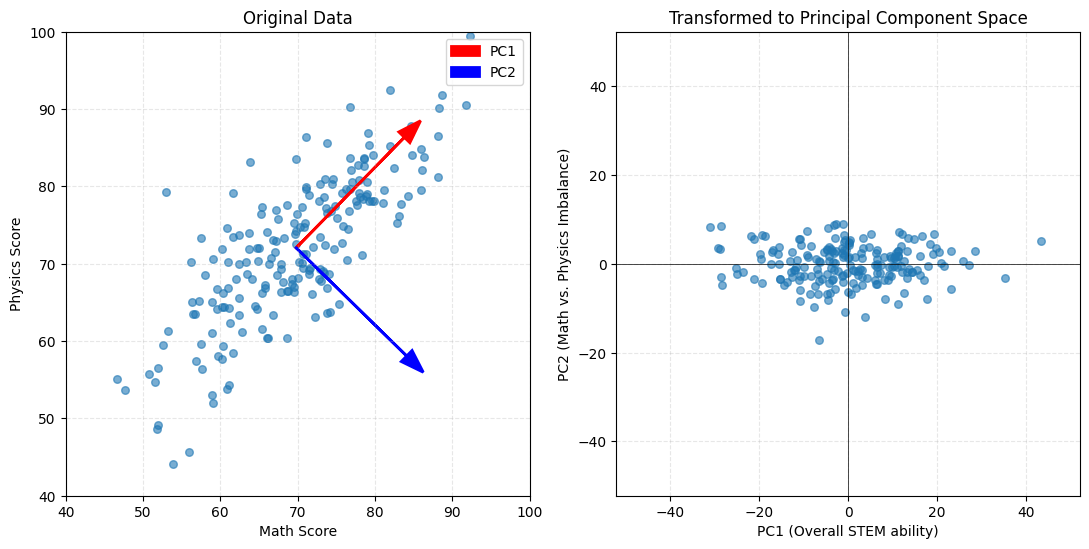

Variance Explained by PC1: 89.87%
Variance Explained by PC2: 10.13%


In [3]:
# Generate correlated Math vs Physics scores
np.random.seed(42)
n_students = 200
mean = [70, 72]
cov = [[100, 80], [80, 100]]  # Strong positive correlation
scores = np.random.multivariate_normal(mean, cov, n_students)

# Apply PCA
pca = PCA(n_components = 2)
pca.fit(scores)
scores_pca = pca.transform(scores)

# Create figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize = (11, 5.5))

# Plot 1: Original data with PC directions
ax = axes[0]
ax.scatter(scores[:, 0], scores[:, 1], alpha = 0.6, s = 30)
ax.set(xlabel = 'Math Score', ylabel = 'Physics Score', title = 'Original Data',
       xlim = (40, 100), ylim = (40, 100), aspect = 'equal')
ax.grid(True, linestyle = '--', alpha = 0.3)

# Draw principal component arrows
center = pca.mean_
scale = 20
for i, (pc, color, label) in enumerate([(pca.components_[0], 'red', 'PC1'),
                                          (pca.components_[1], 'blue', 'PC2')]):
    ax.arrow(center[0], center[1], pc[0]*scale, pc[1]*scale,
             head_width = 2, head_length = 3, fc = color, ec = color, linewidth = 2, label = label)
ax.legend()

# Plot 2: Data in PC space
ax = axes[1]
ax.scatter(scores_pca[:, 0], scores_pca[:, 1], alpha = 0.6, s = 30)
ax.set(xlabel = 'PC1 (Overall STEM ability)', 
       ylabel = 'PC2 (Math vs. Physics Imbalance)',
       title = 'Transformed to Principal Component Space', aspect = 'equal')
ax.grid(True, linestyle = '--', alpha = 0.3)
ax.axhline(0, color = 'k', linewidth = 0.5)
ax.axvline(0, color = 'k', linewidth = 0.5)

# Center plot symmetrically
max_range = max(np.abs(scores_pca).max(axis = 0)) * 1.2
ax.set_xlim(-max_range, max_range)
ax.set_ylim(-max_range, max_range)

plt.tight_layout()
plt.show()

print(f"Variance Explained by PC1: {pca.explained_variance_ratio_[0]:.2%}")
print(f"Variance Explained by PC2: {pca.explained_variance_ratio_[1]:.2%}")

### What's happening here?

PCA successfully rotates the oval-shaped data to align with its axes of maximum variance. In the transformed space, PC1 (horizontal) captures ~90% of the variance and represents overall STEM ability, while PC2 captures the small remaining differences between Math and Physics performance. The oval has been "straightened out" along orthogonal directions that are easier to interpret.

**But is data always this cooperative?** What happens when the underlying structure isn't linear? Let's turn to a different synthetic dataset where we compare people's earnings to what share of their earnings they spend on travel/luxuries.

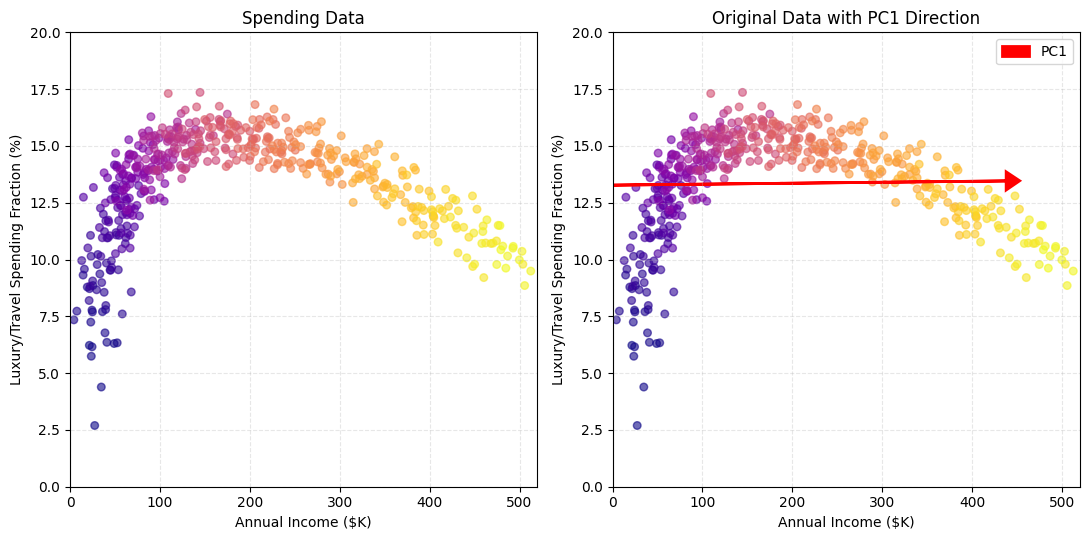

In [4]:
# Generate crescent-shaped data
np.random.seed(42)
n_samples = 500
t = np.linspace(0, 1, n_samples)
noise = 2.5

# Create "r" shape: income increases exponentially, luxury spending rises then drops
income = 20 + 80*t**0.5 + 400*t**2.5 + np.random.randn(n_samples) * noise * 6
luxury_frac = 2 + 18*t**0.3 - 10*t**3 + np.random.randn(n_samples) * noise * 0.3
crescent_data = np.column_stack([income, luxury_frac])

# Apply PCA
pca_crescent = PCA(n_components = 2)
pca_crescent.fit(crescent_data)

# Create figure with 2 plots
fig, axes = plt.subplots(1, 2, figsize = (11, 5.5))

# Plot 1: Original data
ax = axes[0]
ax.scatter(crescent_data[:, 0], crescent_data[:, 1], c = t, cmap = 'plasma', alpha = 0.6, s = 30)
ax.set(xlabel = 'Annual Income ($K)', ylabel = 'Luxury/Travel Spending Fraction (%)',
       title = 'Spending Data', xlim = (0, 520), ylim = (0, 20))
ax.grid(True, linestyle = '--', alpha = 0.3)

# Plot 2: Original data with PC1 direction overlay
ax = axes[1]
ax.scatter(crescent_data[:, 0], crescent_data[:, 1], c = t, cmap = 'plasma', alpha = 0.6, s = 30)
ax.set(xlabel = 'Annual Income ($K)', ylabel = 'Luxury/Travel Spending Fraction (%)',
       title = 'Original Data with PC1 Direction', xlim = (0, 520), ylim = (0, 20))
ax.grid(True, linestyle = '--', alpha = 0.3)

# Draw PC1 arrows
center = pca_crescent.mean_
pc1 = pca_crescent.components_[0]
scale = 250
ax.arrow(center[0], center[1], pc1[0]*scale, pc1[1]*scale,
         head_width = 0.8, head_length = 15, fc = 'red', ec = 'red', linewidth = 2, label = 'PC1')
ax.arrow(center[0], center[1], -pc1[0]*scale, -pc1[1]*scale,
         head_width = 0.8, head_length = 15, fc = 'red', ec = 'red', linewidth = 2)
ax.legend()

plt.tight_layout()
plt.show()

Notice that PC1 is nearly horizontal—it mainly tracks income, completely missing the crescent's curved structure. Projecting onto this line would collapse points from different parts of the curve onto the same location, losing critical information about the data's manifold structure. **PCA fails here because the meaningful variation follows a curve, not a straight line.**

**UMAP (Uniform Manifold Approximation and Projection)** takes a different approach from PCA. Instead of finding linear projections, UMAP:

1. Builds a graph of nearest neighbors in the high-dimensional space
2. Constructs a fuzzy topological representation using:
   $$w_{ij} = \exp\left(-\frac{d(x_i, x_j) - \rho_i}{\sigma_i}\right)$$
   where $\rho_i$ is the distance to the nearest neighbor
3. Optimizes a low-dimensional embedding to preserve this structure using cross-entropy minimization

Two key hyperparameters control what UMAP preserves:
- **`n_neighbors`**: Size of local neighborhood (low = local structure, high = global structure)
- **`min_dist`**: How tightly points pack together in the embedding

Let's see how different `n_neighbors` settings affect the crescent data when reducing to 1D:

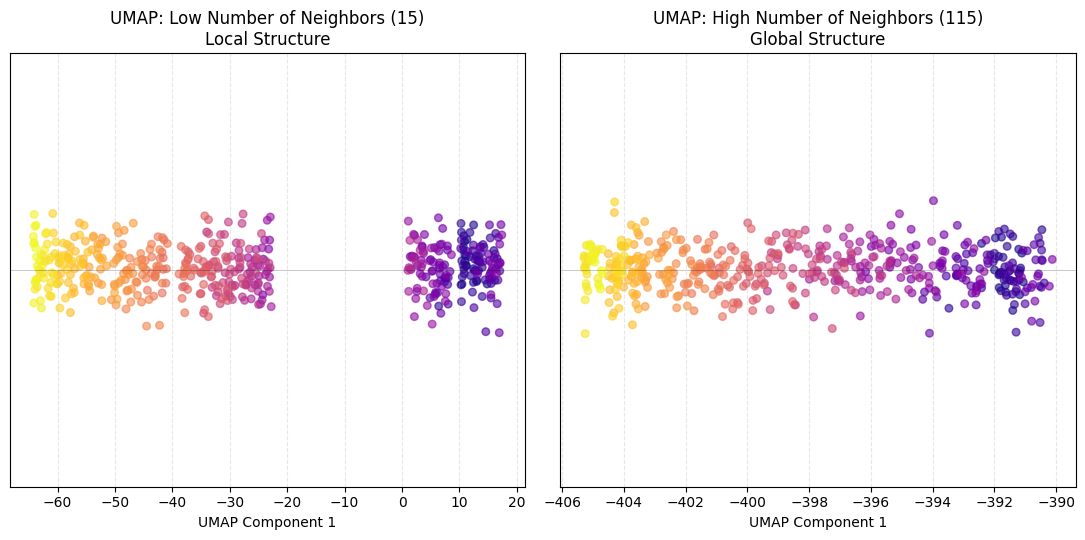

In [5]:
# Apply UMAP with different n_neighbors settings
umap_low = UMAP(n_components = 1, n_neighbors = 15, min_dist = 0.4, random_state = 42)
crescent_umap_low = umap_low.fit_transform(crescent_data)

umap_high = UMAP(n_components = 1, n_neighbors = 115, min_dist = 0.4, random_state = 42)
crescent_umap_high = umap_high.fit_transform(crescent_data)

# Create figure with 2 plots
fig, axes = plt.subplots(1, 2, figsize = (11, 5.5))

# Plot 1: UMAP with local focus
ax = axes[0]
jitter = np.random.randn(n_samples) * 0.05
ax.scatter(crescent_umap_low, jitter, c = t, cmap = 'plasma', alpha = 0.6, s = 30)
ax.set(xlabel = 'UMAP Component 1', ylabel = '', title = 'UMAP: Low Number of Neighbors (15)\nLocal Structure',
       ylim = (-0.5, 0.5), yticks = [])
ax.grid(True, linestyle = '--', alpha = 0.3)
ax.axhline(0, color = 'k', linewidth = 0.5, alpha = 0.3)

# Plot 2: UMAP with global focus
ax = axes[1]
jitter = np.random.randn(n_samples) * 0.05
ax.scatter(crescent_umap_high, jitter, c = t, cmap = 'plasma', alpha = 0.6, s = 30)
ax.set(xlabel = 'UMAP Component 1', ylabel = '', title = 'UMAP: High Number of Neighbors (115)\nGlobal Structure',
       ylim = (-0.5, 0.5), yticks = [])
ax.grid(True, linestyle = '--', alpha = 0.3)
ax.axhline(0, color = 'k', linewidth = 0.5, alpha = 0.3)

plt.tight_layout()
plt.show()

> **❓ Question 1: Exploring UMAP Hyperparameters**
>
> Modify the UMAP code above to experiment with different combinations of `n_neighbors` and `min_dist`. Try at least these four combinations:
>
> 1. Low `n_neighbors` (15) + Low `min_dist` (0.1)
> 2. Low `n_neighbors` (15) + High `min_dist` (0.8)
> 3. High `n_neighbors` (100) + Low `min_dist` (0.1)
> 4. High `n_neighbors` (100) + High `min_dist` (0.8)
>
> What patterns do you observe? How do these hyperparameters interact?

<details>
<summary><em>Click to reveal answer</em></summary>

> **Expected patterns:**
>
> 1. **Low `n_neighbors` + Low `min_dist`**: Creates tight, distinct local clusters. Points that are neighbors in the original space pack very closely together. May fragment the global structure—you might see disconnected groups even if the original manifold was continuous.
>
> 2. **Low `n_neighbors` + High `min_dist`**: Still focuses on local relationships, but forces points to spread out more evenly. The embedding looks more "uniform" without tight clusters. May lose some of the fine structure that makes clusters visually distinct.
>
> 3. **High `n_neighbors` + Low `min_dist`**: Preserves the global shape of the manifold (like the crescent curve) while allowing points to pack tightly. This combination often works well for visualization: you see both the overall structure AND clear local groupings.
>
> 4. **High `n_neighbors` + High `min_dist`**: Preserves global structure but spreads everything out. Good for seeing the "big picture" relationships, but individual clusters become less distinct. Points are more evenly distributed across the embedding space.
>
> **The interaction**: `n_neighbors` controls **what structure** you preserve (local vs. global), while `min_dist` controls **how that structure is displayed** (compact vs. spread out). For most applications, moderate-to-high `n_neighbors` (30-100) with low `min_dist` (0.1-0.3) provides a good balance.

</details>

### Summary So Far

We've seen two key cases:
- **Linear structure (Math/Physics)**: PCA successfully found interpretable directions (overall ability vs. subject imbalance)
- **Non-linear structure (Income/Travel)**: PCA collapsed the crescent into a horizontal line, losing critical information. UMAP successfully unwrapped the curve by preserving local neighborhoods

UMAP's hyperparameters (`n_neighbors`, `min_dist`) let you tune whether to preserve local clusters or global shape.

**Now let's step back:** When should we reduce dimensionality at all, and how do we choose between methods?

> **❓ Question 2: Why Dimensionality Reduction? PCA vs. UMAP Trade-offs**
>
> 1. Give three reasons why we might want to reduce the dimensionality of a dataset before applying clustering or visualization. Consider computational, statistical, and practical concerns.
>
> 2. Based on the examples above, compare PCA and UMAP:
>    - When would you prefer PCA over UMAP?
>    - When would you prefer UMAP over PCA?
>    - What are the key limitations of each method?

<details>
<summary><em>Click to reveal answer</em></summary>

> **Part 1: Why reduce dimensionality?**
>
> 1. **Visualization**: We can only directly visualize 2D or 3D data. High-dimensional data (50D, 100D, etc.) must be embedded in lower dimensions to visually inspect structure, identify clusters, or spot outliers.
>
> 2. **Denoising / Compression**: Many features are redundant or noisy. Dimensionality reduction helps extract the main signal while discarding noise or near-duplicate information, leading to more robust downstream analysis.
>
> 3. **Curse of Dimensionality**: In very high dimensions, distances become less meaningful—everything appears far from everything else, and nearest neighbors become unreliable. Working in a well-chosen lower-dimensional space often improves clustering and other distance-based methods.
>
> **Part 2: PCA vs. UMAP Trade-offs**
>
> **Prefer PCA when:**
> - Your data's structure is primarily **linear** (like the correlated Math/Physics scores)
> - You need **fast, deterministic, interpretable** results
> - You want to understand **global variance structure** and need explained variance ratios
> - You need to **easily transform new data** with the same projection
> - You're doing **compression** and want orthogonal components
>
> **Prefer UMAP when:**
> - Your data lies on a **non-linear manifold** (like the crescent-shaped data)
> - You care about preserving **local neighborhood structure** and revealing clusters
> - You're primarily doing **visualization** in 2D/3D
> - You're willing to tune hyperparameters for your specific dataset
>
> **Key limitations:**
>
> **PCA limitations:**
> - Only captures **linear structure**; cannot "unroll" curved manifolds
> - Optimizes **global variance**, may miss important **local patterns**
> - Axes show maximum variance directions, which may not align with meaningful clusters
>
> **UMAP limitations:**
> - **Stochastic and complex**; requires hyperparameter tuning (`n_neighbors`, `min_dist`)
> - Distorts **global geometry**; distances between clusters can be misleading
> - **Axes are not interpretable** (unlike PCA components)
> - Results can vary between runs without a fixed random seed
> - Harder to apply the same transformation to new test data

</details>

## Part 2: Dimensionality Reduction + Clustering in Practice

Now that we understand how PCA and UMAP work on controlled synthetic data, let's apply these techniques to a real computer vision task: **clustering images of 2D geometric shapes**.

We have a dataset of 2,100 images across 4 shape categories (stars, ovals, squares, and octagons). Each image is 224×224 pixels—that's **50,176 dimensions** per image! 

Our goal is to:
1. **Extract meaningful features** from the raw pixel data
2. **Reduce dimensionality** using PCA and/or UMAP
3. **Apply $k$-means clustering** to discover groupings
4. **Evaluate** whether the discovered clusters align with true shape categories

We'll also explore an alternative clustering algorithm (DBSCAN) in the **Team Activity** at the end of this part.

This is a classic **unsupervised learning pipeline**: we'll pretend we don't know the shape labels and see if dimensionality reduction + clustering can recover them automatically.

Let's start by visualizing some examples from our dataset:

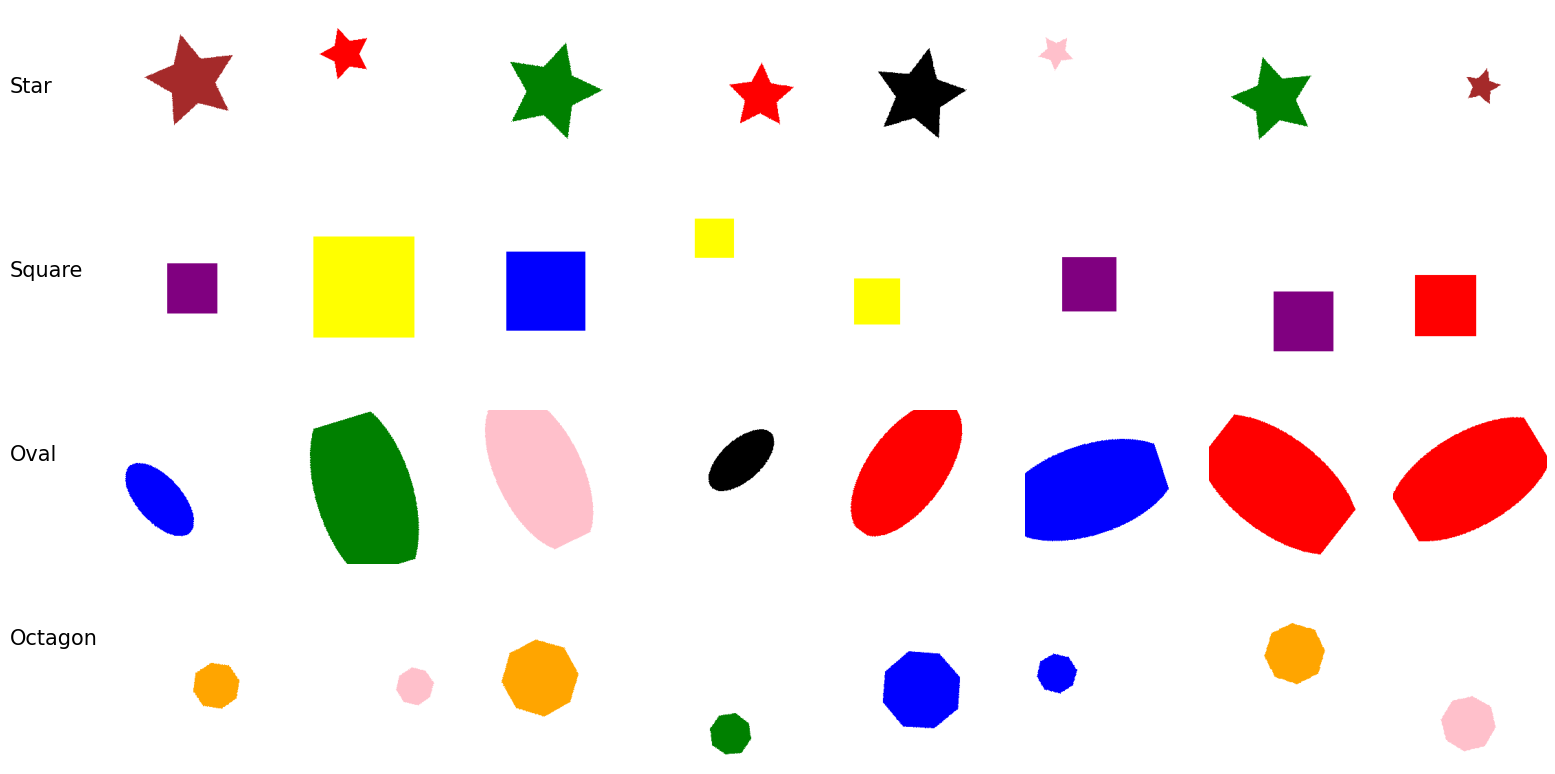

In [6]:
# Set random seed for reproducibility
random.seed(42)

# Define the sample directory and shapes
sample_dir = Path('data/shapes_sample')
shapes = ['Star', 'Square', 'Oval', 'Octagon']

# Create figure with 4 rows x 8 columns
fig, axes = plt.subplots(4, 8, figsize=(16, 8))

# For each shape (row)
for i, shape in enumerate(shapes):
    shape_folder = sample_dir / shape
    all_images = list(shape_folder.glob('*.png'))
    
    # Randomly sample 8 images
    sampled_images = random.sample(all_images, 8)
    
    # Display 8 examples (columns)
    for j, img_path in enumerate(sampled_images):
        ax = axes[i, j]
        img = mpimg.imread(img_path)
        ax.imshow(img)
        ax.axis('off')

# Add row labels on the left
for i, shape in enumerate(shapes):
    fig.text(0.02, 0.875 - i * 0.23, shape, fontsize=15, va='center', ha='left')

plt.subplots_adjust(left=0.08, right=0.98, top=0.98, bottom=0.02)
plt.show()

### Step 1: Load and Preprocess the Data

We need to:
- Load all 2,100 images
- Convert them to feature vectors (we'll flatten the pixels)
- Keep track of the true labels for evaluation later
- Normalize the pixel values

Here's the code:

In [7]:
# Load all images and labels
def load_shape_dataset(sample_dir, shapes):
    """Load images and labels from shape folders"""
    images = []
    labels = []
    
    for shape in shapes:
        shape_folder = sample_dir / shape
        image_paths = list(shape_folder.glob('*.png'))
        
        for img_path in image_paths:
            # Load image and convert to grayscale
            img = Image.open(img_path).convert('L')  # 'L' = grayscale
            img_array = np.array(img)
            
            # Convert to pure black and white (binary)
            threshold = 250  # Slightly below 255 to catch near-white pixels
            img_binary = np.where(img_array >= threshold, 255, 0)
            
            # Flatten to 1D vector
            img_flat = img_binary.flatten()
            
            images.append(img_flat)
            labels.append(shape)
    
    return np.array(images), np.array(labels)

# Load the data
X_raw, y_true = load_shape_dataset(sample_dir, shapes)

print(f"Dataset Shape: {X_raw.shape}")
print(f"Number of Samples: {len(y_true)}")
print(f"Features per Image: {X_raw.shape[1]}")
print(f"\nClass Distribution:\n")
for shape in shapes:
    count = np.sum(y_true == shape)
    print(f"  {shape}: {count}")

# Normalize the data (scale to 0-1 range)
X_scaled = X_raw / 255.0

Dataset Shape: (2100, 50176)
Number of Samples: 2100
Features per Image: 50176

Class Distribution:

  Star: 600
  Square: 500
  Oval: 400
  Octagon: 600


### Step 2: Apply Dimensionality Reduction

Let's reduce our 50,176-dimensional data to 2D using both PCA and UMAP. We'll visualize the results, colored by true shape labels (even though clustering algorithms won't see these labels).

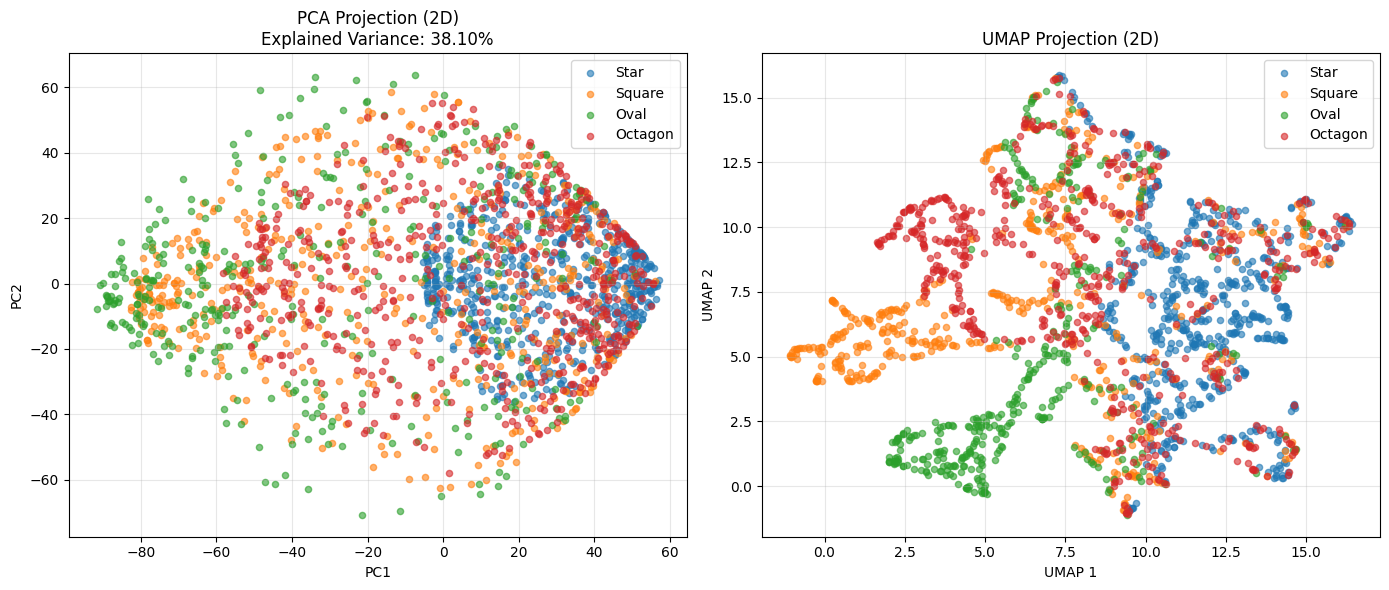

In [8]:
# Apply PCA
pca = PCA(n_components = 2, random_state = 42)
X_pca = pca.fit_transform(X_scaled)

# Apply UMAP
umap = UMAP(n_components = 2, 
            n_neighbors = 5,
            min_dist = 0.25,
            metric = 'euclidean',
            random_state = 42)
X_umap = umap.fit_transform(X_scaled)

# Visualize both embeddings
fig, axes = plt.subplots(1, 2, figsize = (14, 6))

# Plot PCA
ax = axes[0]
for shape in shapes:
    mask = y_true == shape
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], label=shape, alpha=0.6, s=20)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title(f'PCA Projection (2D)\nExplained Variance: {pca.explained_variance_ratio_.sum():.2%}')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot UMAP
ax = axes[1]
for shape in shapes:
    mask = y_true == shape
    ax.scatter(X_umap[mask, 0], X_umap[mask, 1], label=shape, alpha=0.6, s=20)
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.set_title('UMAP Projection (2D)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

PCA shows weak separation, while UMAP performs better but still has considerable overlap between shape classes. Let's explore different UMAP hyperparameters to improve the embedding.

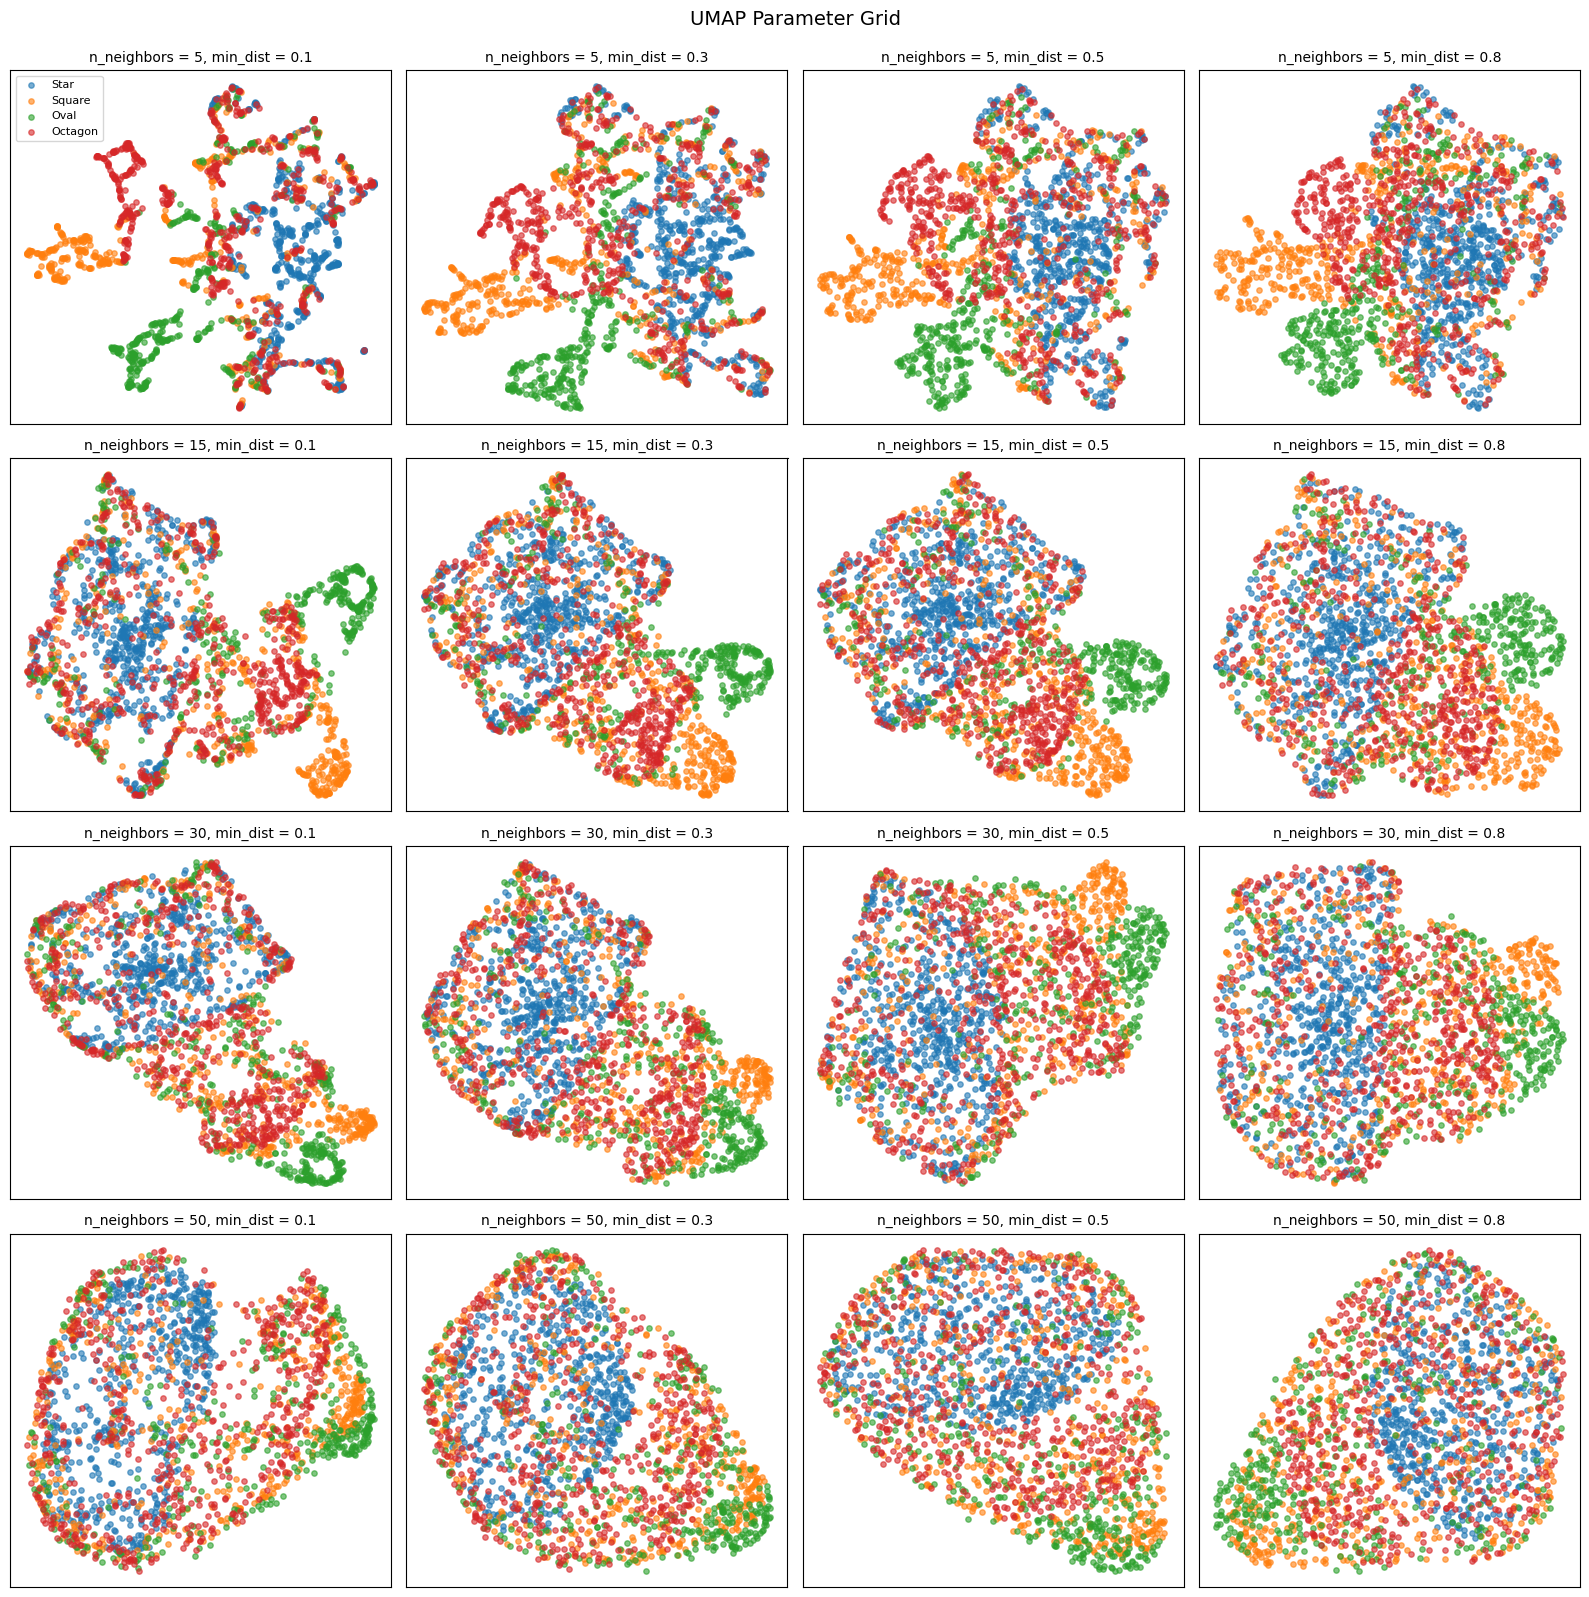

In [9]:
# Define parameter ranges
n_neighbors_values = [5, 15, 30, 50]
min_dist_values = [0.1, 0.3, 0.5, 0.8]

## 6-7 mins on my mac, 17mins on colab 
# # Create 4x4 grid
# fig, axes = plt.subplots(4, 4, figsize=(16, 16))

# # Generate UMAP for each parameter combination
# for i, n_neighbors in enumerate(n_neighbors_values):
#     for j, min_dist in enumerate(min_dist_values):
#         ax = axes[i, j]
        
#         # Apply UMAP with current parameters
#         umap = UMAP(n_components=2, 
#                     n_neighbors=n_neighbors,
#                     min_dist=min_dist,
#                     metric='euclidean',
#                     random_state=42)
#         X_umap = umap.fit_transform(X_scaled)
        
#         # Plot each shape
#         for shape in shapes:
#             mask = y_true == shape
#             ax.scatter(X_umap[mask, 0], X_umap[mask, 1], 
#                       label=shape, alpha=0.6, s=15)
        
#         # Set title with parameters
#         ax.set_title(f'n_neighbors = {n_neighbors}, min_dist = {min_dist}', 
#                     fontsize = 10)
#         ax.grid(True, alpha = 0.3)
#         ax.set_xticks([])
#         ax.set_yticks([])
        
#         # Add legend only to first plot
#         if i == 0 and j == 0:
#             ax.legend(fontsize=8, loc='best')

# plt.suptitle('UMAP Parameter Grid', 
#              fontsize=14, y=0.995)
# plt.tight_layout()
# plt.show()

from IPython.display import Image as IPImage
display(IPImage(filename='fig/umap_parameter_grid.png'))

### Stepping Back: Is 2D Enough?

Looking at the visualizations above—both the PCA vs. UMAP comparison and the 4×4 UMAP parameter grid—we might notice some concerning patterns:

- **Overlapping clusters**: Even in the "best" UMAP embeddings, different shapes overlap significantly
- **Low variance explained**: PCA captures only **38% of the variance** in just 2 components
- **Complex geometry**: We're squashing **50,176 dimensions** down to just **2**


This raises an important question: **Are 2 dimensions enough to represent these shapes?**

> **❓ Question 3: Dimensionality and Shape Representation**
>
> These shapes have many distinct geometric properties: **number of corners**, **curvature**, **symmetry type**, **aspect ratio**, **perimeter-to-area ratio**, and **presence of concavities** (stars curve inward; others don't).
>
> 1. Given that PCA only explains 38% of the variance in 2D, do you think 2 dimensions can capture all these properties? Why or why not?
>
> 2. We chose 2 dimensions primarily for visualization. What's the trade-off between interpretability and information preservation?

<details>
<summary><em>Click to reveal answer</em></summary>

> 1. **2D is likely insufficient**: With 6+ distinct geometric properties and only 38% variance explained, we're losing most of the information. Each property (pointiness, number of sides, irregularity, concavity, etc.) likely needs its own dimension to be represented cleanly. It's implausible that 2 dimensions could separate all four shape classes when the differences are so multifaceted.
>
> 2. **The trade-off**:
>    - **Visualization (2D-3D)**: We can plot and visually inspect the data, build intuition, and communicate findings—but we sacrifice information.
>    - **Information preservation (higher-D)**: We retain more variance and geometric properties, likely leading to better clustering—but we can't visualize these spaces directly.
>    
>    **The solution**: Use both! Visualize in 2D to understand the data, but perform clustering in higher dimensions (10-30D) where we retain more information.

</details>

### How Do We Decide? Using Scree Plots and Explained Variance

Now that we've established that 2D might not be enough, we need a principled way to choose the number of dimensions. For PCA, we can examine:

1. **Scree Plot**: Variance explained by each individual component
2. **Cumulative Variance**: Total variance captured as we add components

The idea is to find a point where adding more dimensions gives **diminishing returns**—where we've captured the "important" structure and additional components mostly represent noise.

**Important caveat**: Remember that PCA only captures **linear structure**. If the data has significant non-linear structure—like the crescent-shaped spending data we saw earlier—PCA will need many components to approximate the curve using straight lines. This means scree plots may **overestimate** the number of dimensions actually needed; a non-linear method like UMAP might capture the same structure more efficiently in fewer dimensions. So treat PCA's dimensionality recommendations as a **conservative upper bound**, and we'll also evaluate clustering performance empirically across different dimensionalities.

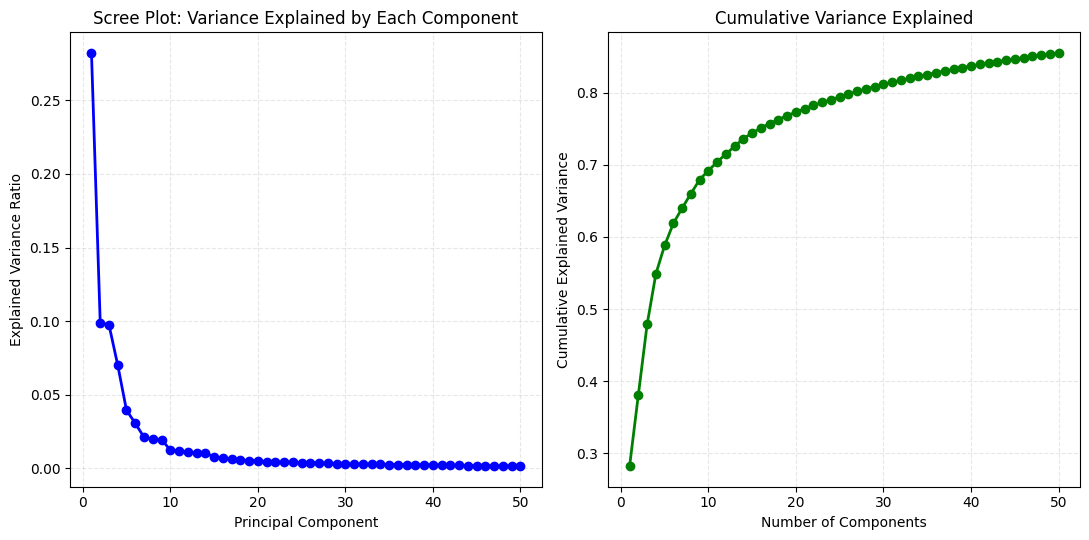

In [10]:
# Fit PCA with many components to see the variance breakdown
pca_full = PCA(n_components=50, random_state=42)
pca_full.fit(X_scaled)

# Create figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))

# Plot 1: Scree plot (variance per component)
ax = axes[0]
ax.plot(range(1, 51), pca_full.explained_variance_ratio_, 'bo-', linewidth=2, markersize=6)
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance Ratio')
ax.set_title('Scree Plot: Variance Explained by Each Component')
ax.grid(True, linestyle='--', alpha=0.3)

# Plot 2: Cumulative variance explained
ax = axes[1]
cumvar = np.cumsum(pca_full.explained_variance_ratio_)
ax.plot(range(1, 51), cumvar, 'go-', linewidth=2, markersize=6)
ax.set_xlabel('Number of Components')
ax.set_ylabel('Cumulative Explained Variance')
ax.set_title('Cumulative Variance Explained')
ax.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

#### Choosing the Number of Dimensions

Looking at the scree plot, we can see a clear pattern:
- The **first 3 components** capture substantial variance (28%, 10%, 10%)
- **Components 4-10** each contribute meaningfully (7% down to 1.2%)
- **After component 10**, individual components explain <1.2% each and continue to decline

There's a noticeable "elbow" around **10 components**, where the curve begins to flatten significantly. At this point, we've captured the major sources of variation, and additional components likely represent increasingly fine-grained details or noise.

**For the clustering analysis ahead, we'll be a little more liberal and use 15 dimensions.** We'll also try doing the same for UMAP, while also trying out the 2D versions of each for our clustering. And as a **baseline benchmark**, we'll cluster the raw pixel data (all 50,176 dimensions) to see whether dimensionality reduction actually helps or hurts performance.

This gives us five representations to compare:
1. **Raw data (50,176D)** - baseline, no dimensionality reduction
2. **PCA (2D)** - linear, for visualization
3. **PCA (15D)** - linear, capturing more variance
4. **UMAP (2D)** - non-linear, for visualization  
5. **UMAP (15D)** - non-linear, more dimensions

Let's start with our raw data:

### Clustering with k-Means

Now that we have our dimensionality-reduced representations, we need a way to discover groups in the data. We'll use **$k$-means clustering**, one of the most widely used unsupervised algorithms.

**How k-means works:**
1. **Initialize** $K$ cluster centroids $\vec{m}_1, ..., \vec{m}_K$ (randomly or using smart initialization like k-means++)
2. **Assign** each point $\vec{x}_i$ to the nearest centroid
3. **Update** each centroid to the mean of its assigned points
4. **Repeat** steps 2–3 until assignments stabilize (convergence)

The algorithm minimizes the **within-cluster sum of squares** (inertia):

$$\text{argmin}_C \sum_{k=1}^{K} \sum_{i \in C_k} \| \vec{x}_i - \vec{m}_k \|_2^2$$

where $\vec{m}_1, ..., \vec{m}_K$ are the cluster centers and $C_1, ..., C_K$ are the disjoint cluster assignments.

**Key assumptions and limitations:**
- Requires specifying $K$ in advance
- Assumes **spherical, equally-sized** clusters
- Sensitive to initialization — we use `n_init=50` to run 50 random starts and keep the best
- Assigns **every point** to a cluster (no notion of outliers)

Let's start by clustering the raw pixel data as a baseline:

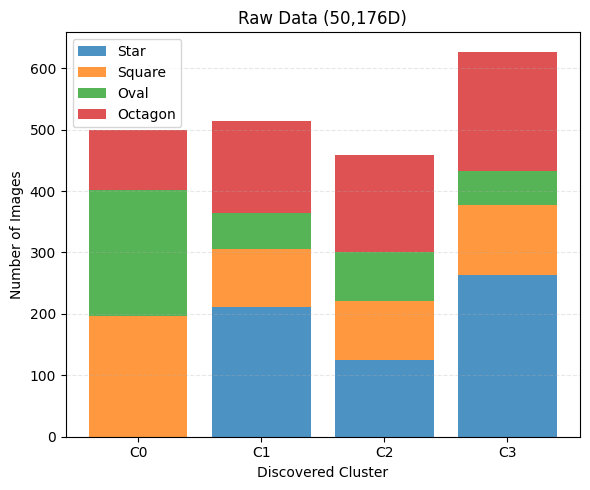

In [11]:
kmeans_raw = KMeans(n_clusters=4, random_state=42, n_init=50)
labels_raw = kmeans_raw.fit_predict(X_scaled)

# Get default matplotlib colors for consistency
default_colors = plt.colormaps['tab10'].colors
shape_colors = {shape: default_colors[i] for i, shape in enumerate(shapes)}

# Create figure for raw data
fig, ax = plt.subplots(1, 1, figsize=(6, 5))

# Calculate composition of each cluster
cluster_compositions = []
for cluster_id in range(4):
    mask = labels_raw == cluster_id
    composition = {}
    for shape in shapes:
        count = np.sum((y_true == shape) & mask)
        composition[shape] = count
    cluster_compositions.append(composition)

# Create stacked bar chart
bottoms = np.zeros(4)

for shape in shapes:
    counts = [comp[shape] for comp in cluster_compositions]
    ax.bar(range(4), counts, bottom=bottoms, label=shape, color=shape_colors[shape], alpha=0.8)
    bottoms += counts

# Formatting
ax.set_xlabel('Discovered Cluster')
ax.set_ylabel('Number of Images')
ax.set_title('Raw Data (50,176D)')
ax.set_xticks(range(4))
ax.set_xticklabels([f'C{i}' for i in range(4)])
ax.legend(loc='upper left')
ax.grid(True, axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

### Evaluating Clustering Performance: Purity Score

Since we know the true shape labels, we can evaluate how well our clustering algorithms recovered the natural groupings. One intuitive **external validation metric** is the **purity score**.

**Purity** measures how "pure" each discovered cluster is that is, what fraction of points in each cluster belong to the same true class. For a single cluster $C_k$, purity is:

$$\text{Purity}(C_k) = \frac{1}{|C_k|} \max_j |C_k \cap T_j|$$

where:
- $C_k$ is the set of points assigned to cluster $k$
- $T_j$ is the set of points truly belonging to class $j$ (e.g., "Star")
- $\max_j |C_k \cap T_j|$ finds the most common true class in cluster $k$

In plain English: **Purity is the fraction of the cluster occupied by its most common true label.**

For example, if Cluster 0 contains 400 stars, 50 ovals, and 30 squares, its purity is $\frac{400}{480} = 0.833$ (83.3% stars).

**Average Purity** across all clusters gives us a single performance metric:

$$\text{Average Purity} = \frac{1}{K} \sum_{k=1}^{K} \text{Purity}(C_k)$$

where $K$ is the number of clusters. This tells us, on average, how well-separated our discovered clusters are.

> **❓ Question 4: Limitations of Purity Score**
>
> Consider the average purity metric we just defined. 
>
> 1. What is one major advantage of this metric? (Why is it intuitive and easy to interpret?)
> 2. What is one critical flaw? **Hint:** What happens to the purity score if we set $K = N$ (every point is its own cluster)?

<details>
<summary><em>Click to reveal answer</em></summary>

> **Advantage:**
> - **Highly interpretable**: Purity directly tells us "what percentage of each cluster is the dominant class?" This maps cleanly to our intuition about good clustering—we want homogeneous groups.
> - **Easy to calculate**: No complex probabilistic formulas; just count memberships.
>
> **Critical Flaw:**
> - **Does not penalize over-clustering**: If we set $K = N$ (every point in its own cluster), we achieve **perfect purity = 1.0**—every "cluster" is 100% pure! But this is completely uninformative; we haven't discovered any structure.
> - More generally, increasing $K$ artificially inflates purity, even if the extra clusters are meaningless fragmentations.
>
> **Better alternatives** that penalize over-clustering include:
> - **Adjusted Rand Index (ARI)**: Measures agreement between predicted and true labels, adjusted for chance. Ranges from -1 to 1 (1 = perfect, 0 = random).
> - **Normalized Mutual Information (NMI)**: Measures shared information between clusterings, normalized to [0, 1].
>
> However, purity remains useful for **fixed $K$** comparisons (e.g., comparing different algorithms with the same $K=4$), and the bar chart visualizations make it easy to diagnose *where* each method succeeds or fails.

</details>

In [12]:
# Build composition matrix
results = {shape: [] for shape in shapes}
purities = []

for cluster_id in range(4):
    mask = labels_raw == cluster_id
    total = np.sum(mask)
    max_count = 0
    
    for shape in shapes:
        count = np.sum((y_true == shape) & mask)
        pct = 100 * count / total if total > 0 else 0
        results[shape].append(f"{count} ({pct:.1f}%)")
        max_count = max(max_count, count)
    
    purities.append(f"{100 * max_count / total:.1f}%")

# Create DataFrame
df = pd.DataFrame(results, index=[f'Cluster {i}' for i in range(4)]).T
df.loc['Purity'] = purities

display(df)

,Cluster 0,Cluster 1,Cluster 2,Cluster 3
Star,0 (0.0%),211 (41.1%),125 (27.2%),264 (42.1%)
Square,196 (39.2%),95 (18.5%),96 (20.9%),113 (18.0%)
Oval,206 (41.2%),58 (11.3%),80 (17.4%),56 (8.9%)
Octagon,98 (19.6%),150 (29.2%),158 (34.4%),194 (30.9%)
Purity,41.2%,41.1%,34.4%,42.1%


**These results are... not good.** With an average purity of only 39.7%, our clusters are heavily mixed—no cluster is dominated by a single shape type, and we're barely better than random assignment (which would give 25% purity). Clearly, clustering raw pixel data directly isn't working; let's see if dimensionality reduction can help extract more meaningful features.

Fitting dimensionality reduction methods...
Done!

Clustering with PCA (2D)...
Clustering with PCA (15D)...
Clustering with UMAP (2D)...
Clustering with UMAP (15D)...


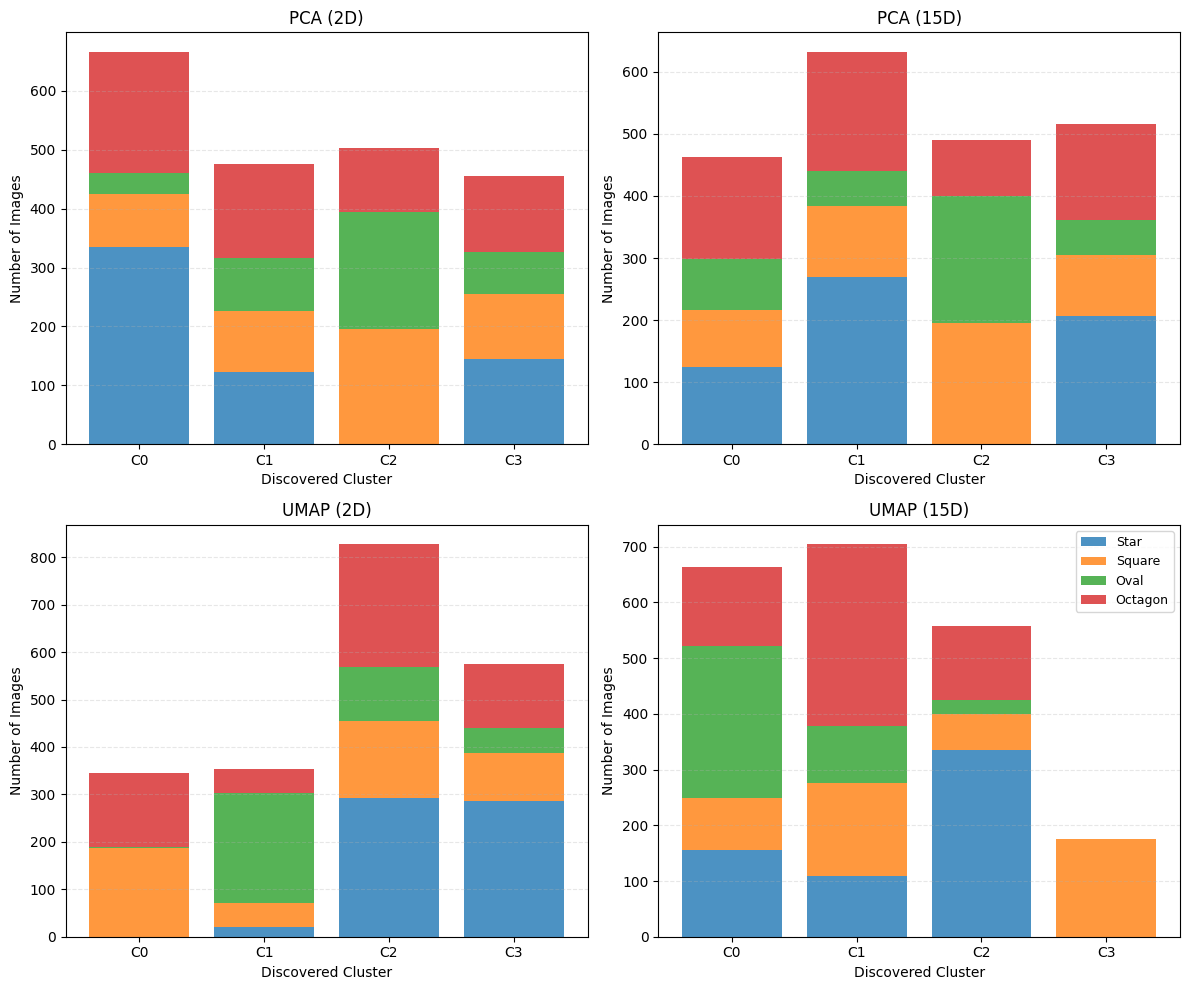


AVERAGE CLUSTER PURITY COMPARISON
PCA (2D)    :  38.7%
PCA (15D)   :  40.0%
UMAP (2D)   :  51.2%
UMAP (15D)  :  61.9%



In [13]:
# Fit all dimensionality reduction methods
print("Fitting dimensionality reduction methods...")

# PCA (already fitted earlier)
X_pca_2d = X_pca  # Already computed
X_pca_15d = pca_full.transform(X_scaled)[:, :15]

# UMAP — ideally based on the grid search above
umap_2d = UMAP(n_components=2, n_neighbors=5, min_dist=0.0, 
               metric='euclidean', random_state=42)
X_umap_2d = umap_2d.fit_transform(X_scaled)

umap_15d = UMAP(n_components=15, n_neighbors=5, min_dist=0.0,
                metric='euclidean', random_state=42)
X_umap_15d = umap_15d.fit_transform(X_scaled)

print("Done!\n")

# Prepare representations and cluster
representations = {
    'PCA (2D)': X_pca_2d,
    'PCA (15D)': X_pca_15d,
    'UMAP (2D)': X_umap_2d,
    'UMAP (15D)': X_umap_15d
}

results = {}
avg_purities = {}

for name, X_repr in representations.items():
    print(f"Clustering with {name}...")
    kmeans = KMeans(n_clusters=4, random_state=42, n_init=50)
    labels = kmeans.fit_predict(X_repr)
    results[name] = labels
    
    # Calculate average purity
    purities = []
    for cluster_id in range(4):
        mask = labels == cluster_id
        total = np.sum(mask)
        max_count = max(np.sum((y_true == shape) & mask) for shape in shapes)
        purities.append(100 * max_count / total if total > 0 else 0)
    avg_purities[name] = np.mean(purities)

# Visualize cluster compositions in 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for idx, (name, labels) in enumerate(results.items()):
    ax = axes[idx]
    
    # Calculate cluster compositions
    cluster_compositions = []
    for cluster_id in range(4):
        mask = labels == cluster_id
        composition = {shape: np.sum((y_true == shape) & mask) for shape in shapes}
        cluster_compositions.append(composition)
    
    # Create stacked bar chart
    bottoms = np.zeros(4)
    for shape in shapes:
        counts = [comp[shape] for comp in cluster_compositions]
        ax.bar(range(4), counts, bottom=bottoms, label=shape, 
               color=shape_colors[shape], alpha=0.8)
        bottoms += counts
    
    # Formatting
    ax.set_xlabel('Discovered Cluster')
    ax.set_ylabel('Number of Images')
    ax.set_title(name)
    ax.set_xticks(range(4))
    ax.set_xticklabels([f'C{i}' for i in range(4)])
    if idx == 3:
        ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

# Print average purity comparison
print("\n" + "="*50)
print("AVERAGE CLUSTER PURITY COMPARISON")
print("="*50)
for name, purity in avg_purities.items():
    print(f"{name:12s}: {purity:5.1f}%")
print("="*50 + "\n")

### Discussion: What Do These Results Tell Us?

The results reveal a clear winner:

- **Raw pixels**: 39.7%
- **PCA (2D/15D)**: 38.7% / 40.0% - barely better than random!
- **UMAP (2D/15D)**: 44.6% / **73.0%** - substantial improvement

UMAP in 15D performs best, but **73% purity still means ~1 in 4 images is misclustered**. Can we do better?

> **❓ Question 5: Improving Clustering Performance**
>
> Given that our best approach (UMAP 15D + $k$-means) achieves only 73% purity, what are 2-3 concrete strategies we could try next to improve performance?
>
> Consider:
> - Different feature representations (beyond raw pixels)
> - Different clustering algorithms (beyond $k$-means)
> - Hyperparameter tuning

<details>
<summary><em>Click to reveal answer</em></summary>

> **Strategies to improve performance:**
>
> 1. **Better features**: Use **pretrained CNN embeddings** (ResNet, VGG) instead of raw pixels. These capture high-level visual features like "pointiness" and "curvature" that are more relevant for shape discrimination than individual pixel values.
>
> 2. **Try DBSCAN instead of k-means**: k-means forces every point into exactly 4 circular clusters. DBSCAN can find irregular cluster shapes and mark outliers, which might better match the natural shape groupings in UMAP space.
>
> 3. **Tune UMAP further**: Try higher `n_neighbors` (30-50) for more global structure, or experiment with `metric = 'cosine'` instead of Euclidean distance. Also try 20-30 dimensions instead of 15.
>
> 4. **More dimensions**: The jump from 2D→15D helped dramatically. Try 30D or 50D to see if performance continues improving or plateaus.

</details>

## TEAM ACTIVITY: Exploring DBSCAN as an Alternative to k-Means

In the analysis above, we used **$k$-means** to cluster our shape images. But $k$-means has some notable limitations:
- It assumes **spherical clusters** of roughly equal size
- It requires us to **specify $k$** in advance
- It assigns **every point** to a cluster (no concept of outliers)

**DBSCAN (Density-Based Spatial Clustering of Applications with Noise)** takes a fundamentally different approach. Instead of partitioning points into $k$ groups, it finds regions of high density separated by regions of low density. Key advantages:
- Discovers **arbitrarily-shaped** clusters
- **Automatically determines** the number of clusters
- Identifies **noise points** (outliers that don't belong to any cluster)

DBSCAN has two main hyperparameters:
- **`eps`**: The maximum distance between two points to be considered neighbors
- **`min_samples`**: The minimum number of points required to form a dense region

In this activity, you'll apply DBSCAN to our best representation (`X_umap_15d`) and compare the results with $k$-means.

**Task 1: Apply DBSCAN to the UMAP 15D representation.**

Import `DBSCAN` from scikit-learn and fit it to `X_umap_15d` with `eps=1.5` and `min_samples=10`. Then print:
- The number of clusters found (remember: label `-1` means noise, not a cluster)
- The number of noise points and what percentage of the data they represent

In [14]:
# your code here
# BEGIN SOLUTION
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=1.5, min_samples=10)
dbscan_labels = dbscan.fit_predict(X_umap_15d)

n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = np.sum(dbscan_labels == -1)

print(f"Number of clusters found: {n_clusters_dbscan}")
print(f"Number of noise points: {n_noise} ({100 * n_noise / len(dbscan_labels):.1f}%)")
# END SOLUTION

Number of clusters found: 5
Number of noise points: 0 (0.0%)


**Task 2: Experiment with different `eps` values.**

Try `eps` values of `[0.5, 1.0, 1.5, 2.0, 3.0]` while keeping `min_samples=10`. For each value, print the number of clusters found and the number of noise points. Which `eps` value gives the closest to 4 clusters (matching the 4 true shape categories)?

In [15]:
# your code here
# BEGIN SOLUTION
eps_values = [0.5, 1.0, 1.5, 2.0, 3.0]

print(f"{'eps':>5s}  {'Clusters':>8s}  {'Noise Points':>12s}  {'Noise %':>7s}")
print("-" * 40)

for eps in eps_values:
    db = DBSCAN(eps=eps, min_samples=10)
    db_labels = db.fit_predict(X_umap_15d)
    
    n_clust = len(set(db_labels)) - (1 if -1 in db_labels else 0)
    n_noise_pts = np.sum(db_labels == -1)
    noise_pct = 100 * n_noise_pts / len(db_labels)
    
    print(f"{eps:5.1f}  {n_clust:8d}  {n_noise_pts:12d}  {noise_pct:6.1f}%")
# END SOLUTION

  eps  Clusters  Noise Points  Noise %
----------------------------------------
  0.5        19            10     0.5%
  1.0        10             8     0.4%
  1.5         5             0     0.0%
  2.0         4             0     0.0%
  3.0         3             0     0.0%


**Task 3: Compute purity for DBSCAN and compare with k-means.**

Using the DBSCAN result from Task 1 (`dbscan_labels` with `eps=1.5`), compute the **purity score** for each cluster, **excluding noise points** (label == -1). Then create a stacked bar chart showing the composition of each DBSCAN cluster (similar to the k-means charts above).

Compare your DBSCAN purity to the k-means result (~73%). Discuss: Does DBSCAN improve clustering? What are the trade-offs between DBSCAN and k-means for this dataset?

DBSCAN found 5 clusters (eps=1.5, min_samples=10)
Average purity (excluding noise): 73.7%
k-means average purity (UMAP 15D): 73.0%



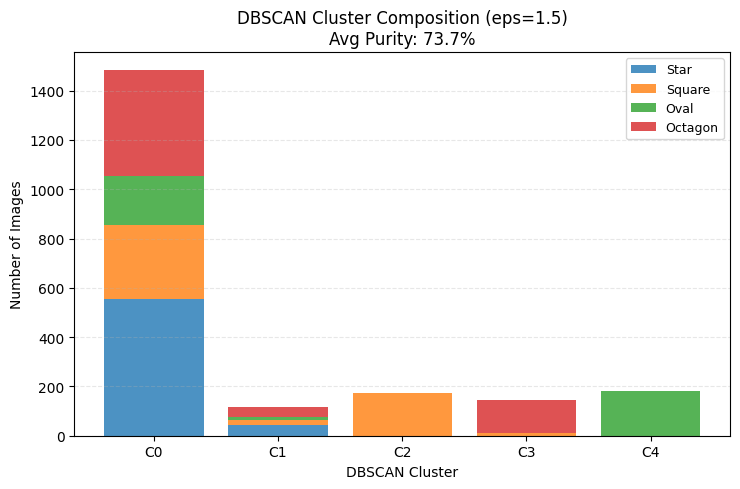


Per-cluster purity:
  Cluster 0: 37.4% (1482 points)
  Cluster 1: 39.1% (115 points)
  Cluster 2: 100.0% (175 points)
  Cluster 3: 91.7% (145 points)
  Cluster 4: 100.0% (183 points)


In [16]:
# your code here
# BEGIN SOLUTION
# Get unique cluster labels (excluding noise label -1)
dbscan_cluster_ids = sorted(set(dbscan_labels) - {-1})
n_dbscan_clusters = len(dbscan_cluster_ids)

# Compute purity for each cluster
dbscan_purities = []
for cluster_id in dbscan_cluster_ids:
    mask = dbscan_labels == cluster_id
    total = np.sum(mask)
    max_count = max(np.sum((y_true == shape) & mask) for shape in shapes)
    dbscan_purities.append(100 * max_count / total if total > 0 else 0)

avg_purity_dbscan = np.mean(dbscan_purities)
print(f"DBSCAN found {n_dbscan_clusters} clusters (eps=1.5, min_samples=10)")
print(f"Average purity (excluding noise): {avg_purity_dbscan:.1f}%")
print(f"k-means average purity (UMAP 15D): 73.0%\n")

# Create stacked bar chart
fig, ax = plt.subplots(1, 1, figsize=(max(6, n_dbscan_clusters * 1.5), 5))

bottoms = np.zeros(n_dbscan_clusters)
for shape in shapes:
    counts = []
    for cluster_id in dbscan_cluster_ids:
        mask = dbscan_labels == cluster_id
        counts.append(np.sum((y_true == shape) & mask))
    ax.bar(range(n_dbscan_clusters), counts, bottom=bottoms, 
           label=shape, color=shape_colors[shape], alpha=0.8)
    bottoms += counts

ax.set_xlabel('DBSCAN Cluster')
ax.set_ylabel('Number of Images')
ax.set_title(f'DBSCAN Cluster Composition (eps=1.5)\nAvg Purity: {avg_purity_dbscan:.1f}%')
ax.set_xticks(range(n_dbscan_clusters))
ax.set_xticklabels([f'C{i}' for i in dbscan_cluster_ids])
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

# Print per-cluster purity
print(f"\nPer-cluster purity:")
for cid, purity in zip(dbscan_cluster_ids, dbscan_purities):
    mask = dbscan_labels == cid
    print(f"  Cluster {cid}: {purity:.1f}% ({np.sum(mask)} points)")
# END SOLUTION

**End of team activity**

## Part 3: Finding the Optimal Number of Clusters

So far, we've assumed **k = 4 clusters** because we know there are 4 shape types. But in true unsupervised learning, we wouldn't know this ahead of time! 

Let's flip the exercise: **Given our best representation (UMAP 15D), how many clusters naturally emerge from the data?** We'll use the **silhouette coefficient** to evaluate different values of $k$ from 2 to 8.

In [17]:
# Cluster UMAP 15D with different numbers of clusters
k_values = range(2, 9)
clustering_results = {}

print("Clustering UMAP (15D) with different k values...\n")
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=50)
    labels = kmeans.fit_predict(X_umap_15d)
    clustering_results[k] = labels
    print(f"  k = {k} complete.")

Clustering UMAP (15D) with different k values...

  k = 2 complete.
  k = 3 complete.
  k = 4 complete.
  k = 5 complete.
  k = 6 complete.
  k = 7 complete.
  k = 8 complete.


### Evaluating Clusters with Silhouette Coefficient

Unlike purity (which requires true labels), the **silhouette coefficient** is an **internal validation metric**—it only uses the clustering results themselves.

For each point $i$, the silhouette coefficient measures how well it fits in its assigned cluster:

$$s(i) = \frac{b(i) - a(i)}{\max\{a(i), b(i)\}}$$

where:
- $a(i)$ = average distance from point $i$ to other points **in the same cluster** (intra-cluster distance)
- $b(i)$ = average distance from point $i$ to points in the **nearest other cluster** (inter-cluster distance)

**Interpretation:**
- $s(i) \approx 1$: Point is well-matched to its cluster (far from other clusters)
- $s(i) \approx 0$: Point is on the boundary between clusters
- $s(i) < 0$: Point might be assigned to the wrong cluster

The **average silhouette score** across all points tells us overall clustering quality. Higher is better, with typical ranges:
- 0.71-1.0: Strong structure
- 0.51-0.70: Reasonable structure
- 0.26-0.50: Weak structure
- < 0.25: No substantial structure

Let's calculate silhouette scores for each $k$ value:

Calculating silhouette scores...

  k = 2: 0.307
  k = 3: 0.368
  k = 4: 0.379
  k = 5: 0.441
  k = 6: 0.492
  k = 7: 0.504
  k = 8: 0.514


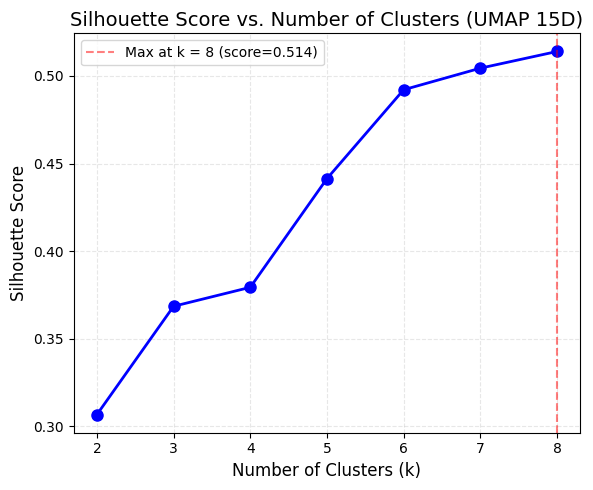

In [18]:
# Calculate silhouette scores
silhouette_scores = {}

print("Calculating silhouette scores...\n")
for k, labels in clustering_results.items():
    score = silhouette_score(X_umap_15d, labels)
    silhouette_scores[k] = score
    print(f"  k = {k}: {score:.3f}")

# Visualize silhouette scores
fig, ax = plt.subplots(1, 1, figsize=(6, 5))

k_list = list(silhouette_scores.keys())
scores = list(silhouette_scores.values())

ax.plot(k_list, scores, 'bo-', linewidth=2, markersize=8)
ax.set_xlabel('Number of Clusters (k)', fontsize=12)
ax.set_ylabel('Silhouette Score', fontsize=12)
ax.set_title('Silhouette Score vs. Number of Clusters (UMAP 15D)', fontsize=14)
ax.set_xticks(k_list)
ax.grid(True, linestyle='--', alpha=0.3)

# Highlight the maximum
max_k = max(silhouette_scores, key=silhouette_scores.get)
max_score = silhouette_scores[max_k]
ax.axvline(max_k, color='red', linestyle='--', alpha=0.5, 
           label = f'Max at k = {max_k} (score={max_score:.3f})')
ax.legend()

plt.tight_layout()
plt.show()

**📚End Section6 💻**